<h1 style="font-size: 300%; font-weight: 100"><span style="font-size: 60%">Part 3:</span><br>Higgs hunting </h1>

In this part of the ATLAS FP experiemnt we will be trying to discover Higgs boson!
You will be working with Run1 dataset that in part led to Higgs discovery in 2012 (see https://arxiv.org/abs/1207.7214)
In particularly, we will be looking into Higgs decaying into 4l (via ZZ*),

<div style="border: 1px solid black; padding: 1em">
    About this notebook: Tasks are marked with <b>Assignemnt</b>, places where
    you need to add code are marked with <code># TODO</code>.
</div>

In [1]:
from glob import glob
import uproot as up
import numpy as np
import matplotlib.pyplot as plt
import atlasify as atl
atl.ATLAS = "FP2 - ATLAS"  # Do not remove
from atlasify import atlasify
from collections import OrderedDict
import itertools
import ROOT
import Higgsutils as fpu
import awkward as ak

/home/tushar/miniconda3/envs/ATLAS_env/lib/python3.13/site-packages/ROOT/__init__.py:5: UserWarning: 
This distribution of ROOT is in alpha stage. Feedback is welcome and appreciated. Feel free to reach out to the user forum for questions and general feedback at https://root-forum.cern.ch or to submit an issue at https://github.com/root-project/root/issues. Do not rely on this distribution for production purposes.

  warnings.warn(
/home/tushar/miniconda3/envs/ATLAS_env/lib/python3.13/site-packages/cppyy/__init__.py:374: UserWarning: CPyCppyy API not found (tried: /home/tushar/miniconda3/envs/ATLAS_env/include/site/python3.13); set CPPYY_API_PATH envar to the 'CPyCppyy' API directory to fix
  warnings.warn("CPyCppyy API not found (tried: %s); "


In [ ]:
#Running for the first time you might have to install additional packages (please uncomment the line below)
#%pip install --user -r requirements.txt

In [2]:
# Let's make sure we have a directory where we want to dump plots to
%mkdir -p plots

# Dataset & [akward arrays](https://awkward-array.org/quickstart.html) intro

In previous parts we were using pandas dataframe to get through the event info. Pandas is very well performant however, it can only be used for 'square' datasets (do your recall that we had in all events el1 and el2 even though we did not have two electrons in all events). In this part, however, we are daling with ntuples where each event has different structure (different number of jets, different number of leptons). 

Pandas is no good for such a dataset, we will be using [akward arrays](https://awkward-array.org/quickstart.html) instead.

**Assignment:**  Please explore dataset available to us in this part, by running and modifying the code below.

In [6]:
folder_name = "/home/tushar/Documents/Freiburg_courses/FP-Lab/ATLAS/ATLAS_Experiment/data/ntuple_part4/"

root_file = up.open(folder_name + "Data8TeV.root")
ttree = root_file["eventTree"]
akward = ttree.arrays() # mind the difference compare to pandas dataframe loading

In [ ]:
# One can list fileds available with the command below:
ak.fields(akward)

['RunNumber',
 'nlep',
 'lep_E',
 'lep_pt',
 'lep_eta',
 'lep_phi',
 'lep_ptiso',
 'lep_etiso',
 'lep_charge',
 'lep_id',
 'lep_d0',
 'lep_d0sig',
 'lep_z0',
 'lep_z0sig',
 'njet',
 'jet_E',
 'jet_pt',
 'jet_eta',
 'jet_phi',
 'sumet',
 'met',
 'met_phi',
 'mc_GenWeight',
 'mc_EvtWeight',
 'hfor_type',
 'm_mc_channel_number',
 'EF_e24vhi_medium1',
 'EF_e60_medium1',
 'EF_2e12Tvh_loose1',
 'EF_mu24i_tight',
 'EF_mu36_tight',
 'EF_2mu13',
 'EF_mu18_tight_mu8_EFFS',
 'EF_e12Tvh_medium1_mu8',
 'EF_e24vhi_loose1_mu8',
 'xsec',
 'nevts',
 'isData']

In [ ]:
#This is how we can pull information on specific leptons:

In [11]:
# 35 equidistant bins, centered around from -3.5 to 3.5
hist_nlep = ROOT.TH1F("", "nlep", 10, 0, 10)  # nlep
hist_pt_lep1 = ROOT.TH1F("", "Electron 1", 40, 0, 400)  # pt lep1
hist_pt_lep4 = ROOT.TH1F("", "Electron 4", 40, 0, 400)  # pt lep4
hist_pt_jet1 = ROOT.TH1F("", "Jet1", 40, 0, 400)  # pt jet1
hist_pt_jet2 = ROOT.TH1F("", "Jet2", 40, 0, 400)  # pt jet2

# Loop over chunks of data:
# Performant way of iterating over all events in akward array (the function internally has changed compare to W/Z-parts of the execrcise, but the workflow is almost identical)
fpu.fill_histo(akward.nlep, hist_nlep)
fpu.fill_histo(akward.lep_pt[akward.nlep>0,0], hist_pt_lep1) # mind that now for each event lep_pt is a table. We can loop over all events selecting only leading leptons! 
fpu.fill_histo(akward.lep_pt[akward.nlep>3,3], hist_pt_lep4)
fpu.fill_histo(akward.jet_pt[akward.njet>0,0], hist_pt_jet1)
fpu.fill_histo(akward.jet_pt[akward.njet>1,1], hist_pt_jet2)

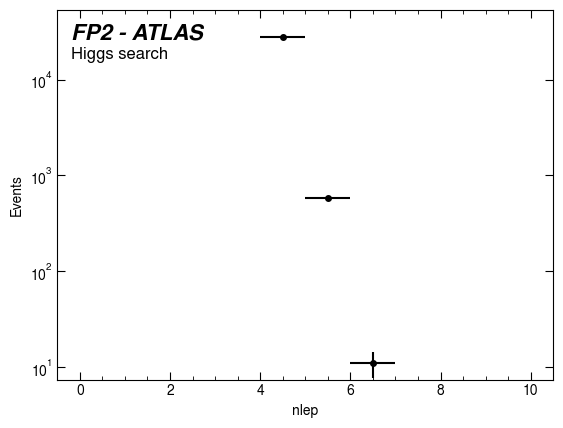

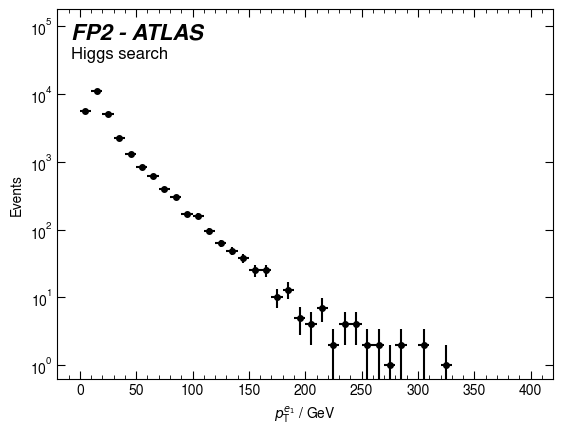

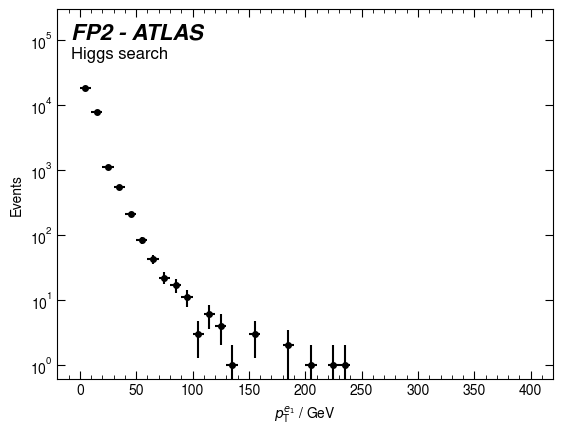

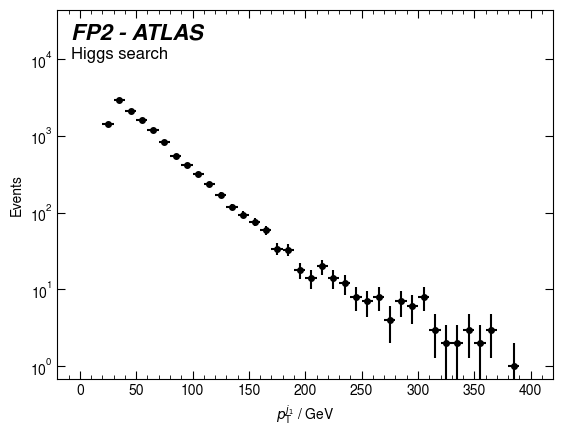

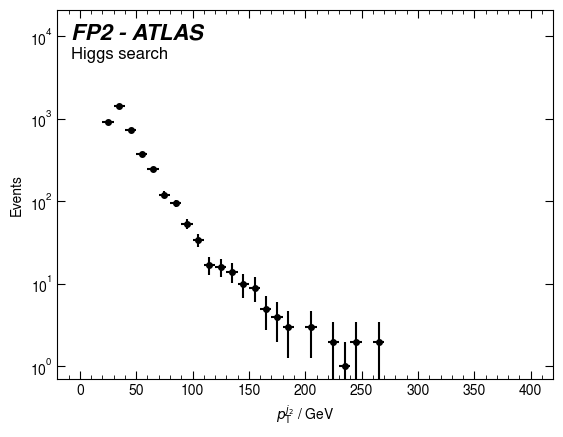

In [12]:
# And let's have a quick plot of the functions
ax=fpu.hist_points(hist_nlep)
ax.set_xlabel('nlep')
ax.set_ylabel('Events')
plt.yscale('log')
atl.atlasify(subtext="Higgs search")

ax=fpu.hist_points(hist_pt_lep1)
ax.set_xlabel('$p_\mathrm{T}^{e_1}$ / GeV')
ax.set_ylabel('Events')
plt.yscale('log')
atl.atlasify(enlarge=10.0,subtext="Higgs search")

ax=fpu.hist_points(hist_pt_lep4)
ax.set_xlabel('$p_\mathrm{T}^{e_1}$ / GeV')
ax.set_ylabel('Events')
plt.yscale('log')
atl.atlasify(enlarge=10.0,subtext="Higgs search")

ax=fpu.hist_points(hist_pt_jet1)
ax.set_xlabel('$p_\mathrm{T}^{j_1}$ / GeV')
ax.set_ylabel('Events')
plt.yscale('log')
atl.atlasify(enlarge=10.0,subtext="Higgs search")

ax=fpu.hist_points(hist_pt_jet2)
ax.set_xlabel('$p_\mathrm{T}^{j_2}$ / GeV')
ax.set_ylabel('Events')
plt.yscale('log')
atl.atlasify(enlarge=10.0,subtext="Higgs search")

**Assignment:** Try to plot several other variables and think about the distributions. In particular:
* Why there are at least 4 leptons in the dataset? 
* Some events contains jets. Do we expect jets from our targeted signal events? 

# Useful functions

We define functions for plotting that we are going to use through the notebook

In [13]:
def default_plot(histogram_stack_ref, x_label,data_blind=True,data_name='data',
                     background_names=['ggH125', 'VBFH125', 'WH125', 'ZH125', 'ttH125', 'ZZ', 'WZ', 'Zee', 'Zeebb', 'Zmumu', 'Zmumubb', 'Ztautau', 'Top'],
                     y_label=None, axes=None):
    """
    Draws histograms for data & MC from histogram_stack
    
    Inputs:
        histogram_stack -- data hist must be on the first place
        x_label         -- x axis label
        
    optional inputs:
        y_label         -- y axis label
        axes            -- matplotlib.axes object where to plot
    """
    if axes is None:
        fig, axes = plt.subplots()
    
    for sample_name in background_names+[data_name]:
        if(sample_name not in histogram_stack_ref):
            print(f"Sample {sample_name} not found in histogram_stack! Check your inputs!")
    
    if(data_blind):
        histogram_stack=fpu.blind_data(histogram_stack_ref,data_name,background_names)
    else:
        histogram_stack=histogram_stack_ref
    data = histogram_stack[data_name]
    
    backgrounds = [histogram_stack[name] for name in background_names]
    fpu.hist_stack(*backgrounds, axes=axes)
    fpu.hist_points(data, axes=axes)
    fpu.reverse_legend(axes=axes,ncol=2,labelspacing=0.3,columnspacing=0.5)
    atlasify(subtext="Higgs search",axes=axes)
    axes.set_xlabel(x_label, ha='right', x=0.95)
    if(not y_label):
        bin_width = backgrounds[0].GetXaxis().GetBinWidth(1)
        y_label=f"Events / {bin_width:g} GeV"
    axes.set_ylabel(y_label, ha='right', y=0.95)
    return axes

In [14]:
def default_ratio_plot(histogram_stack_ref, x_label,data_blind=True,data_name='data',
                        background_names=['ggH125', 'VBFH125', 'WH125', 'ZH125', 'ttH125', 'ZZ', 'WZ', 'Zee', 'Zeebb', 'Zmumu', 'Zmumubb', 'Ztautau', 'Top'],
                       y_label=None,axes=(None,None)):
    """
    Draws histograms for data & MC from histogram_stack with data/MC ratio as well
    
    Inputs:
        histogram_stack -- data hist must be on the first place
        x_label         -- x axis label
        
    optional inputs:
        y_label         -- y axis label
        axes            -- matplotlib.axes object where to plot
    """
    
    if(None in axes):
        fig, axes = plt.subplots(nrows=2, sharex='col', gridspec_kw={'height_ratios': [5, 1]})

    histogram_stack=histogram_stack_ref.copy()
    for sample_name in background_names+[data_name]:
        if(sample_name not in histogram_stack_ref):
            print(f"Sample {sample_name} not found in histogram_stack! Check your inputs!")

    if(data_blind):
        histogram_stack=fpu.blind_data(histogram_stack_ref,data_name,background_names)
    else:
        histogram_stack=histogram_stack_ref
    
    # Draw top panel using already define default_plot
    default_plot(histogram_stack, '',data_blind,y_label=y_label, axes=axes[0])    
    
    # Create ratio plot between data & mc
    # for this ROOT is amazingly simple
    data = histogram_stack[data_name]
    backgrounds = [histogram_stack[name] for name in background_names]
    hBkg=fpu.sum_histograms(backgrounds)
    
    hRatio=histogram_stack[data_name].Clone()
    hRatio.Divide(hBkg)
    fpu.hist_points(hRatio, axes=axes[1])
    
    # Error on data is statistic. We can also plot stat error on raw number of MC events:
    ratio_bkg_uncertainty=np.array([hBkg.GetBinError(i)/hBkg.GetBinContent(i) if hBkg.GetBinContent(i)>0 else 0. for i in range(1,hBkg.GetNbinsX()+1)])
    bins = fpu.edges(hRatio)
    axes[1].hist(bins[:-1], bins=bins,
              weights=2*ratio_bkg_uncertainty,
              bottom=1+-1 * ratio_bkg_uncertainty,
              histtype='stepfilled', zorder=0,
              fill=False, hatch='/////',
              linewidth=0, edgecolor="#666666")
    axes[1].set_xlabel(x_label, ha='right', x=0.95)
    axes[1].set_ylabel('data/MC', ha='center', x=0.95)
    axes[1].set_ylim(0.5,1.5)
    xLimits=[hRatio.GetXaxis().GetXmin(),hRatio.GetXaxis().GetXmax()]
    axes[1].plot(xLimits,[1,1],c='k',linewidth=0.1)
    axes[1].figure.align_ylabels()
    #fig.tight_layout()
    return (axes)

# Full analysis 

Inside `Higgsutils/__init__.py` helpful functions are provided that are similar to Zee & Wmass parts. 

In [18]:
# Luminosity of the data sample we are using is needed to correctly normalise our MC samples to it.
# Here we use ATLAS 8TeV data from Run1 corresponding to total integrated luminosity of ~20.7 fb-1

analysis = fpu.Analysis(luminosity_fb=20.7)

# add_sample method attaches sample to the analysis object specifying its type (fake/MC background/MC signal)

# Data
analysis.add_sample("data", "Data",[folder_name + "Data8TeV.root"],
                   meta_data={"signal": False, "data": True, "mc": False})

#Signal
analysis.add_sample("ggH125","ggH125",[folder_name + "ggHZZ1258TeV.root"],
                   meta_data={"signal": True, "data": False, "mc": True});
analysis.add_sample("VBFH125","VBFH125",[folder_name + "VBFHZZ1258TeV.root"],
                   meta_data={"signal": True, "data": False, "mc": True});
analysis.add_sample("WH125","WH125",[folder_name + "WHZZ1258TeV.root"],
                   meta_data={"signal": True, "data": False, "mc": True});
analysis.add_sample("ZH125","ZH125",[folder_name + "ZHZZ1258TeV.root"],
                   meta_data={"signal": True, "data": False, "mc": True});
analysis.add_sample("ttH125","TH125",[folder_name + "ttHZZ1258TeV.root"],
                   meta_data={"signal": True, "data": False, "mc": True});

#Backgrounds
analysis.add_sample("ZZ","ZZ",[folder_name + "ZZ8TeV.root"],
                   meta_data={"signal": False, "data": False, "mc": True});
analysis.add_sample("WZ","WZ",[folder_name + "WZ8TeV.root"],
                   meta_data={"signal": False, "data": False, "mc": True});
analysis.add_sample("Zee","Zee",[folder_name + "Zee8TeV.root"],
                   meta_data={"signal": False, "data": False, "mc": True});
analysis.add_sample("Zeebb","Zeebb",[folder_name + "Zeebb8TeV.root"],
                   meta_data={"signal": False, "data": False, "mc": True});
analysis.add_sample("Zmumu","Zmumu",[folder_name + "Zmumu8TeV.root"],
                   meta_data={"signal": False, "data": False, "mc": True});
analysis.add_sample("Zmumubb","Zmumubb",[folder_name + "Zmumubb8TeV.root"],
                   meta_data={"signal": False, "data": False, "mc": True});
analysis.add_sample("Ztautau","Ztautau",[folder_name + "Ztautau8TeV.root"],
                   meta_data={"signal": False, "data": False, "mc": True});
analysis.add_sample("Top","Top",[folder_name + "Top8TeV.root"],
                   meta_data={"signal": False, "data": False, "mc": True});

In [19]:
analysis.files

[['/home/tushar/Documents/Freiburg_courses/FP-Lab/ATLAS/ATLAS_Experiment/data/ntuple_part4/Data8TeV.root'],
 ['/home/tushar/Documents/Freiburg_courses/FP-Lab/ATLAS/ATLAS_Experiment/data/ntuple_part4/ggHZZ1258TeV.root'],
 ['/home/tushar/Documents/Freiburg_courses/FP-Lab/ATLAS/ATLAS_Experiment/data/ntuple_part4/VBFHZZ1258TeV.root'],
 ['/home/tushar/Documents/Freiburg_courses/FP-Lab/ATLAS/ATLAS_Experiment/data/ntuple_part4/WHZZ1258TeV.root'],
 ['/home/tushar/Documents/Freiburg_courses/FP-Lab/ATLAS/ATLAS_Experiment/data/ntuple_part4/ZHZZ1258TeV.root'],
 ['/home/tushar/Documents/Freiburg_courses/FP-Lab/ATLAS/ATLAS_Experiment/data/ntuple_part4/ttHZZ1258TeV.root'],
 ['/home/tushar/Documents/Freiburg_courses/FP-Lab/ATLAS/ATLAS_Experiment/data/ntuple_part4/ZZ8TeV.root'],
 ['/home/tushar/Documents/Freiburg_courses/FP-Lab/ATLAS/ATLAS_Experiment/data/ntuple_part4/WZ8TeV.root'],
 ['/home/tushar/Documents/Freiburg_courses/FP-Lab/ATLAS/ATLAS_Experiment/data/ntuple_part4/Zee8TeV.root'],
 ['/home/tusha

## Initial selections

Let's plot signal and background distributions for selected kinematic distributions

In [ ]:
for akw, meta_data, sample in analysis.akward_iterate(fraction=0.1):
    
    break

In [21]:
help(fpu.sort_leptons_by_pt)

Help on function sort_leptons_by_pt in module Higgsutils:

sort_leptons_by_pt(akw_array)



In [24]:
from importlib.metadata import version
version('Awkward')

'2.9.0'

In [20]:
# Define histogram stacks you want
# stacks and not just normal histograms as we want to have one histogram for each production process

h_pt_lep = analysis.TH1F_stack(20, 0, 200)
h_pt_lep1 = analysis.TH1F_stack(20, 0, 200)
h_pt_lep2 = analysis.TH1F_stack(20, 0, 200)
h_pt_lep3 = analysis.TH1F_stack(20, 0, 200)
h_pt_lep4 = analysis.TH1F_stack(20, 0, 200)

h_eta_lep = analysis.TH1F_stack(30, -3, 3)
h_eta_lep1 = analysis.TH1F_stack(30, -3, 3)
h_eta_lep2 = analysis.TH1F_stack(30, -3, 3)
h_eta_lep3 = analysis.TH1F_stack(30, -3, 3)
h_eta_lep4 = analysis.TH1F_stack(30, -3, 3)

h_phi_lep = analysis.TH1F_stack(20, -3.2, 3.2)
h_phi_lep1 = analysis.TH1F_stack(20, -3.2, 3.2)
h_phi_lep2 = analysis.TH1F_stack(20, -3.2, 3.2)

h_ptiso_el = analysis.TH1F_stack(40, -0.3, 1)
h_etiso_el = analysis.TH1F_stack(40, -0.3, 1)
h_ptiso_mu = analysis.TH1F_stack(40, -0.3, 1)
h_etiso_mu = analysis.TH1F_stack(40, -0.3, 1)

h_d0sig_el = analysis.TH1F_stack(20, -10, 10)
h_z0sig_el = analysis.TH1F_stack(20, -10, 10)
h_d0sig_mu = analysis.TH1F_stack(20, -10, 10)
h_z0sig_mu = analysis.TH1F_stack(20, -10, 10)

h_nlep = analysis.TH1F_stack(10, 0, 10)
h_njet = analysis.TH1F_stack(10, 0, 10)

h_m12 = analysis.TH1F_stack(60 ,0.,300)
h_m34 = analysis.TH1F_stack(60 ,0.,300)
h_mllll = analysis.TH1F_stack(60 ,0.,300)

# Fill the histograms:

for akw, meta_data, sample in analysis.akward_iterate(fraction=0.1):



    # Necessary trigger & overlap-removal cuts:
    akw=fpu.preselection_cuts(akw)
    
    # The leptons & jets are by default not sorted. 
    # We sort them below by pT
    akw=fpu.sort_leptons_by_pt(akw)
    akw=fpu.sort_jets_by_pt(akw)
    akw=fpu.add_invariant_masses(akw)
    
    # Calculate correct event weight
    weights = ak.where(akw.isData==False,analysis.luminosity*akw.xsec*akw.mc_EvtWeight/akw.nevts,1)
    
    test=ak.broadcast_arrays(akw.lep_pt,weights)
    fpu.fill_histo(ak.flatten(test[0]), h_pt_lep[sample], weights=ak.flatten(test[1]))
    fpu.fill_histo(akw.lep_pt[:,0], h_pt_lep1[sample], weights=weights)
    fpu.fill_histo(akw.lep_pt[:,1], h_pt_lep2[sample], weights=weights)
    fpu.fill_histo(akw.lep_pt[:,2], h_pt_lep3[sample], weights=weights)
    fpu.fill_histo(akw.lep_pt[:,3], h_pt_lep4[sample], weights=weights)

    #fpu.fill_histo(akw.lep_eta, h_eta_lep[sample], weights=weights)
    fpu.fill_histo(akw.lep_eta[:,0], h_eta_lep1[sample], weights=weights)
    fpu.fill_histo(akw.lep_eta[:,1], h_eta_lep2[sample], weights=weights)
    fpu.fill_histo(akw.lep_eta[:,2], h_eta_lep3[sample], weights=weights)
    fpu.fill_histo(akw.lep_eta[:,3], h_eta_lep4[sample], weights=weights)

    #fpu.fill_histo(akw.lep_phi, h_phi_lep1[sample], weights=weights)
    fpu.fill_histo(akw.lep_phi[:,0], h_phi_lep1[sample], weights=weights)
    fpu.fill_histo(akw.lep_phi[:,1], h_phi_lep2[sample], weights=weights)

    # el_ptiso and el_etiso (includes all electrons)
    tmp_weights_el_ptiso=ak.broadcast_arrays(weights,akw.lep_ptiso[akw.lep_id==11]) # needed to expand weight to multiple electrons per event
    fpu.fill_histo(ak.flatten(tmp_weights_el_ptiso[1]), h_ptiso_el[sample], weights=ak.flatten(tmp_weights_el_ptiso[0]))
    tmp_weights_el_etiso=ak.broadcast_arrays(weights,akw.lep_etiso[akw.lep_id==11]) # needed to expand weight to multiple electrons per event
    fpu.fill_histo(ak.flatten(tmp_weights_el_etiso[1]), h_etiso_el[sample], weights=ak.flatten(tmp_weights_el_etiso[0]))

    # mu_ptiso and mu_etiso (includes all muons)
    tmp_weights_mu_ptiso=ak.broadcast_arrays(weights,akw.lep_ptiso[akw.lep_id==13]) # needed to expand weight to multiple muons per event
    fpu.fill_histo(ak.flatten(tmp_weights_mu_ptiso[1]), h_ptiso_mu[sample], weights=ak.flatten(tmp_weights_mu_ptiso[0]))
    tmp_weights_mu_etiso=ak.broadcast_arrays(weights,akw.lep_etiso[akw.lep_id==13]) # needed to expand weight to multiple muons per event
    fpu.fill_histo(ak.flatten(tmp_weights_mu_etiso[1]), h_etiso_mu[sample], weights=ak.flatten(tmp_weights_mu_etiso[0]))
    

    
    fpu.fill_histo(akw.nlep, h_nlep[sample], weights=weights)
    fpu.fill_histo(akw.njet, h_njet[sample], weights=weights)

    fpu.fill_histo(akw.m12, h_m12[sample], weights=weights)
    fpu.fill_histo(akw.m34, h_m34[sample], weights=weights)
    fpu.fill_histo(akw.mllll, h_mllll[sample], weights=weights)

AttributeError: fields cannot be set as attributes. use #__setitem__ or #ak.with_field

In [ ]:
default_ratio_plot(h_pt_lep1,"$p_\mathrm{T}^{e_1}$ / GeV")
plt.savefig("plots/lep_pt_ratioPlot_prefit.pdf")

In [ ]:
(ax1,ax2)=default_ratio_plot(h_mllll,"$M_{4l}$ / GeV")
ax1.set_xlim(0,300)
atl.atlasify(enlarge=1,axes=ax1)
plt.savefig("plots/post_sel_mllll.pdf")

In [ ]:
default_ratio_plot(h_pt_lep,"$p_\mathrm{T}^{all\ lep.}$ / GeV",y_label='# of laptons')
(ax1,ax2)=default_ratio_plot(h_pt_lep,"$p_\mathrm{T}^{all\ lep.}$ / GeV",y_label='# of laptons',data_blind=False)
plt.savefig("plots/All_lep_pt_prefit.pdf")

### Scan variables

`ScanHistograms` is a method that will help you find out best cut values
It plots normalised signal and background, as well as cumulative $s/\sqrt{b}$ ratio for different cuts. 

Can you make sense of what the method is doing and what is the difference between `isUp` being True or False?

In [ ]:
# Example of how to use the ScanHistogram method. Do you understand what is plotted?
analysis.ScanHistograms(h_pt_lep1,x_label='$p_\mathrm{T}^{l_1}$ / GeV')
analysis.ScanHistograms(h_pt_lep1,x_label='$p_\mathrm{T}^{l_1}$ / GeV',isUp=True)

**Assignement** Use ScanHistograms method to plot cumulative $s/\sqrt{b}$ for different cuts. Using this come up with best values of cuts to use in `user_selection`

## Analysis selections

**Assignment**: Please come up with the selection criteria to select Higgs events. Apply the cuts in the `user_selection` function below. Motivate your choices with plots!

In [ ]:
def user_selection(akw,meta_data):
    """
    Returns a new akward array with only a subset of events, selected for the
    analysis.
    """

    # TODO Think about general cuts that all events need to satisfy

    
    # Require 4-leptons
    akw=akw[akw.nlep>=4]
    
    # Leading lepton pT cuts
    akw=akw[akw.lep_pt[:,0]>0] # leading lepton pT
    akw=akw[akw.lep_pt[:,1]>0] # subleading lepton pT
    akw=akw[akw.lep_pt[:,2]>0] # 3rd leading lepton pT
    akw=akw[akw.lep_pt[:,3]>0] # 4th leading lepton pT
    
    #Require lepton isolation
    akw=akw[ak.all(akw.lep_ptiso[akw.lep_id==11]<999,axis=1)] # electron ptiso
    akw=akw[ak.all(akw.lep_etiso[akw.lep_id==11]<999,axis=1)] # electron etiso
    akw=akw[ak.all(akw.lep_ptiso[akw.lep_id==13]<999,axis=1)] # muon ptiso
    akw=akw[ak.all(akw.lep_etiso[akw.lep_id==13]<999,axis=1)] # muon etiso
    
    #Require cut on the impact parameter or the impact parameter significance
    akw=akw[ak.all((abs(akw.lep_d0)/akw.lep_d0sig)[akw.lep_id==11]<999,axis=1)] # electron
    akw=akw[ak.all((abs(akw.lep_d0)/akw.lep_d0sig)[akw.lep_id==13]<999,axis=1)] # muon
    
    akw=akw[akw.m12>0.0]
    akw=akw[akw.m12<999]
    akw=akw[akw.m34>0.0]
    akw=akw[akw.m34<999]
    #akw=akw[akw.mllll>0.]
    #akw=akw[akw.mllll<999]
            
    return akw

In [ ]:
# Define histogram stacks you want
# stacks and not just normal histograms as we want to have one histogram for each production process

h_pt_lep = analysis.TH1F_stack(20, 0, 200)
h_pt_lep1 = analysis.TH1F_stack(20, 0, 200)
h_pt_lep2 = analysis.TH1F_stack(20, 0, 200)
h_pt_lep3 = analysis.TH1F_stack(20, 0, 200)
h_pt_lep4 = analysis.TH1F_stack(20, 0, 200)

h_eta_lep = analysis.TH1F_stack(30, -3, 3)
h_eta_lep1 = analysis.TH1F_stack(30, -3, 3)
h_eta_lep2 = analysis.TH1F_stack(30, -3, 3)
h_eta_lep3 = analysis.TH1F_stack(30, -3, 3)
h_eta_lep4 = analysis.TH1F_stack(30, -3, 3)

h_phi_lep = analysis.TH1F_stack(20, -3.2, 3.2)
h_phi_lep1 = analysis.TH1F_stack(20, -3.2, 3.2)
h_phi_lep2 = analysis.TH1F_stack(20, -3.2, 3.2)

h_ptiso_el = analysis.TH1F_stack(40, -0.3, 1)
h_etiso_el = analysis.TH1F_stack(40, -0.3, 1)
h_ptiso_mu = analysis.TH1F_stack(40, -0.3, 1)
h_etiso_mu = analysis.TH1F_stack(40, -0.3, 1)

h_d0sig_el = analysis.TH1F_stack(20, -10, 10)
h_z0sig_el = analysis.TH1F_stack(20, -10, 10)
h_d0sig_mu = analysis.TH1F_stack(20, -10, 10)
h_z0sig_mu = analysis.TH1F_stack(20, -10, 10)

h_nlep = analysis.TH1F_stack(10, 0, 10)
h_njet = analysis.TH1F_stack(10, 0, 10)

h_m12 = analysis.TH1F_stack(60 ,0.,300)
h_m34 = analysis.TH1F_stack(60 ,0.,300)
h_mllll = analysis.TH1F_stack(60 ,0.,300)

# Fill the histograms:

for akw, meta_data, sample in analysis.akward_iterate(fraction=0.1):



    # Necessary trigger & overlap-removal cuts:
    akw=fpu.preselection_cuts(akw)
    
    # The leptons & jets are by default not sorted. 
    # We sort them below by pT
    akw=fpu.sort_leptons_by_pt(akw)
    akw=fpu.sort_jets_by_pt(akw)
    akw=fpu.add_invariant_masses(akw)
    
    # Apply user cuts on events
    akw=user_selection(akw,meta_data)
    
    # Calculate correct event weight
    weights = ak.where(akw.isData==False,analysis.luminosity*akw.xsec*akw.mc_EvtWeight/akw.nevts,1)
    
    test=ak.broadcast_arrays(akw.lep_pt,weights)
    fpu.fill_histo(ak.flatten(test[0]), h_pt_lep[sample], weights=ak.flatten(test[1]))
    fpu.fill_histo(akw.lep_pt[:,0], h_pt_lep1[sample], weights=weights)
    fpu.fill_histo(akw.lep_pt[:,1], h_pt_lep2[sample], weights=weights)
    fpu.fill_histo(akw.lep_pt[:,2], h_pt_lep3[sample], weights=weights)
    fpu.fill_histo(akw.lep_pt[:,3], h_pt_lep4[sample], weights=weights)

    #fpu.fill_histo(akw.lep_eta, h_eta_lep[sample], weights=weights)
    fpu.fill_histo(akw.lep_eta[:,0], h_eta_lep1[sample], weights=weights)
    fpu.fill_histo(akw.lep_eta[:,1], h_eta_lep2[sample], weights=weights)
    fpu.fill_histo(akw.lep_eta[:,2], h_eta_lep3[sample], weights=weights)
    fpu.fill_histo(akw.lep_eta[:,3], h_eta_lep4[sample], weights=weights)

    #fpu.fill_histo(akw.lep_phi, h_phi_lep1[sample], weights=weights)
    fpu.fill_histo(akw.lep_phi[:,0], h_phi_lep1[sample], weights=weights)
    fpu.fill_histo(akw.lep_phi[:,1], h_phi_lep2[sample], weights=weights)

    # el_ptiso and el_etiso (includes all electrons)
    tmp_weights_el_ptiso=ak.broadcast_arrays(weights,akw.lep_ptiso[akw.lep_id==11]) # needed to expand weight to multiple electrons per event
    fpu.fill_histo(ak.flatten(tmp_weights_el_ptiso[1]), h_ptiso_el[sample], weights=ak.flatten(tmp_weights_el_ptiso[0]))
    tmp_weights_el_etiso=ak.broadcast_arrays(weights,akw.lep_etiso[akw.lep_id==11]) # needed to expand weight to multiple electrons per event
    fpu.fill_histo(ak.flatten(tmp_weights_el_etiso[1]), h_etiso_el[sample], weights=ak.flatten(tmp_weights_el_etiso[0]))

    # mu_ptiso and mu_etiso (includes all muons)
    tmp_weights_mu_ptiso=ak.broadcast_arrays(weights,akw.lep_ptiso[akw.lep_id==13]) # needed to expand weight to multiple muons per event
    fpu.fill_histo(ak.flatten(tmp_weights_mu_ptiso[1]), h_ptiso_mu[sample], weights=ak.flatten(tmp_weights_mu_ptiso[0]))
    tmp_weights_mu_etiso=ak.broadcast_arrays(weights,akw.lep_etiso[akw.lep_id==13]) # needed to expand weight to multiple muons per event
    fpu.fill_histo(ak.flatten(tmp_weights_mu_etiso[1]), h_etiso_mu[sample], weights=ak.flatten(tmp_weights_mu_etiso[0]))
    

    
    fpu.fill_histo(akw.nlep, h_nlep[sample], weights=weights)
    fpu.fill_histo(akw.njet, h_njet[sample], weights=weights)

    fpu.fill_histo(akw.m12, h_m12[sample], weights=weights)
    fpu.fill_histo(akw.m34, h_m34[sample], weights=weights)
    fpu.fill_histo(akw.mllll, h_mllll[sample], weights=weights)

In [ ]:
default_ratio_plot(h_pt_lep1,"$p_\mathrm{T}^{e_1}$ / GeV")



plt.savefig("plots/lep_pt_ratioPlot_prefit.pdf")

In [ ]:
(ax1,ax2)=default_ratio_plot(h_mllll,"$M_{4l}$ / GeV")



ax1.set_xlim(0,300)
atl.atlasify(enlarge=1,axes=ax1)
plt.savefig("plots/post_sel_mllll.pdf")

In [ ]:
default_ratio_plot(h_pt_lep,"$p_\mathrm{T}^{all\ lep.}$ / GeV",y_label='# of laptons')



plt.savefig("plots/All_lep_pt_prefit.pdf")

### Scan variables

Plotting scan variables again, after applying `user_selection`, will be a good test of your cuts' efficiency

In [ ]:
analysis.ScanHistograms(h_pt_lep1,x_label='$p_\mathrm{T}^{l_1}$ / GeV')
analysis.ScanHistograms(h_pt_lep1,x_label='$p_\mathrm{T}^{l_1}$ / GeV',isUp=True)

**Assignement** If you are done with selection, plot the distribution(`default_ratio_plot` above) with `data_blind=False`. What is the agreement between data and MC? Discuss the level of the agreement with your tutor.

# p-value scans

With the `user_selection` finalised we can focus on statistical analysis.

**Assignment** Please run the code below. What does it do? What is the p-value? What is the difference between observed and expected p-value? 

**Assignment** Are you selection criteria good enough to claim Higgs discovery?

In [ ]:
# Luminosity of the data sample we are using is needed to correctly normalise our MC samples to it.
# Here we use ATLAS 8TeFalseV data from Run1 corresponding to total integrated luminosity of ~20.7 fb-1

analysis_pValue = fpu.Analysis(luminosity_fb=20.7)

# add_sample method attaches sample to the analysis object specifying its type (data/fake/MC background/MC signal)

# Data
analysis_pValue.add_sample("data", "Data",["data/Data8TeV.root"],
                   meta_data={"signal": False, "data": True, "mc": False})

#Signals
analysis_pValue.add_sample("Signal110","Signal110",["data/Signal1108TeV.root"], 
                          meta_data={"signal": True, "data": False, "mc": True,"HiggsMass":110});
analysis_pValue.add_sample("Signal115","Signal115",["data/Signal1158TeV.root"], 
                          meta_data={"signal": True, "data": False, "mc": True,"HiggsMass":115});
analysis_pValue.add_sample("Signal125","Signal125",["data/Signal1258TeV.root"], 
                          meta_data={"signal": True, "data": False, "mc": True,"HiggsMass":125});
analysis_pValue.add_sample("Signal135","Signal135",["data/Signal1358TeV.root"], 
                          meta_data={"signal": True, "data": False, "mc": True,"HiggsMass":135});
analysis_pValue.add_sample("Signal145","Signal145",["data/Signal1458TeV.root"], 
                          meta_data={"signal": True, "data": False, "mc": True,"HiggsMass":145});
analysis_pValue.add_sample("Signal155","Signal155",["data/Signal1558TeV.root"], 
                          meta_data={"signal": True, "data": False, "mc": True,"HiggsMass":155});
analysis_pValue.add_sample("Signal165","Signal165",["data/Signal1658TeV.root"], 
                          meta_data={"signal": True, "data": False, "mc": True,"HiggsMass":165});
analysis_pValue.add_sample("Signal175","Signal175",["data/Signal1758TeV.root"], 
                          meta_data={"signal": True, "data": False, "mc": True,"HiggsMass":175});

#Backgrounds
analysis_pValue.add_sample("ZZ","ZZ",["data/ZZ8TeV.root"],
                   meta_data={"signal": False, "data": False, "mc": True});
analysis_pValue.add_sample("WZ","WZ",["data/WZ8TeV.root"],
                   meta_data={"signal": False, "data": False, "mc": True});
analysis_pValue.add_sample("Zee","Zee",["data/Zee8TeV.root"],
                   meta_data={"signal": False, "data": False, "mc": True});
analysis_pValue.add_sample("Zeebb","Zeebb",["data/Zeebb8TeV.root"],
                   meta_data={"signal": False, "data": False, "mc": True});
analysis_pValue.add_sample("Zmumu","Zmumu",["data/Zmumu8TeV.root"],
                   meta_data={"signal": False, "data": False, "mc": True});
analysis_pValue.add_sample("Zmumubb","Zmumubb",["data/Zmumubb8TeV.root"],
                   meta_data={"signal": False, "data": False, "mc": True});
analysis_pValue.add_sample("Ztautau","Ztautau",["data/Ztautau8TeV.root"],
                   meta_data={"signal": False, "data": False, "mc": True});
analysis_pValue.add_sample("Top","Top",["data/Top8TeV.root"],
                   meta_data={"signal": False, "data": False, "mc": True});

In [ ]:
h_mllll_pVal = analysis_pValue.TH1F_stack(120 ,0.,300)


for akw, meta_data, sample in analysis_pValue.akward_iterate(fraction=0.1):



  
    # Necessary trigger & overlap-removal cuts:
    akw=fpu.preselection_cuts(akw)
    
    # The leptons & jets are by default not sorted. 
    # We sort them below by pT
    akw=fpu.sort_leptons_by_pt(akw)
    akw=fpu.sort_jets_by_pt(akw)
    akw=fpu.add_invariant_masses(akw)
    
    # Apply user cuts on events
    akw=user_selection(akw,meta_data)
    
    # Calculate correct event weight
    weights = ak.where(akw.isData==False,analysis_pValue.luminosity*akw.xsec*akw.mc_EvtWeight/akw.nevts,1)
    
    fpu.fill_histo(akw.mllll, h_mllll_pVal[sample], weights=weights)    

In [ ]:
pvalues,ax=analysis_pValue.PValue(h_mllll_pVal,scan_window=10)

In [ ]:
pvalues,ax=analysis_pValue.PValue(h_mllll_pVal,scan_window=5,observed=True)

**Assignment** Try to understand what the code above does. Consult `Higgsutils/__init__.py` file. Following signal distributions will help you:

In [ ]:
default_plot(h_mllll_pVal,"$p_\mathrm{T}^{e_1}$ / GeV",data_blind=True, background_names=[k for k in h_mllll_pVal if 'Signal' in k])

In [ ]:
fig, axes = plt.subplots()
for signal in [k for k in h_mllll_pVal if 'Signal' in k]:
    fpu.hist_line(h_mllll_pVal[signal],axes=axes,lw=2)
fpu.reverse_legend()
axes.set_xlabel(r"$M_{4l}$ / GeV", ha='right', x=0.95)
axes.set_ylabel('Events', ha='left', x=0.95) 
atl.atlasify(subtext="Higgs search",axes=axes)
plt.savefig("plots/HiggsSampleDistributions.pdf")

# Fractional fit

**Assignement** Run fractional fit (fitting signal & background relative compositions) below. Have you discovered Higgs? Is it produced as expected from the SM?

In [ ]:
ax=analysis.FractionFit(100,140,h_mllll)
ax.figure.savefig('plots/FractionFitRsults.pdf')

# Invariant mass distribution fit. 

**Assignement** Run the fit below. What kind of model is fitted? Any idea why? What results do you get? Do your results agree in all the parts?

In [ ]:
fig, ax = plt.subplots()
fit_range=(100,180)
myfit = ROOT.TF1("myfit","[0]*exp(-0.5*((x-[1])/[2])^2)+[3]+[4]*x+[5]*x^2",fit_range[0],fit_range[1]);
myfit.SetParameter(1, 125.);
myfit.SetParameter(2, 10.);
myfit.SetParameter(3, 3.);
hdata2 = h_mllll['data'].Clone();
hdata2.Fit("myfit","R0");
default_plot(h_mllll, '$M_{4l}$ / GeV',data_blind=False,axes=ax)
xVal=np.linspace(fit_range[0],fit_range[1],100)
yVal=[myfit.Eval(x) for x in xVal]
plt.plot(xVal,yVal,color='r',lw=2)
atl.atlasify()